# Pairs Trading Strategy Using Statistical Arbitrage

### Nathan Jarvis

### What is statistical arbitrage and pairs trading?

Statistical arbitrage involves using quantitative models to identify price inefficiencies between related assets or securities. It’s a more complex form of arbitrage that doesn’t rely on obvious price differences across markets, but rather on statistical relationships like cointegration, mean reversion, or correlation between pairs of assets.

Cointegration ≠ Correlation

Cointegration refers to a long-term statistical relationship between two or more time series that share a common trend, even if their individual paths may fluctuate. Correlation, on the other hand, simply measures how closely the two assets' prices move together at any given time, without considering long-term trends or mean reversion. While two assets may be correlated in the short term, this doesn't necessarily mean they are cointegrated or will revert to a long-term equilibrium.

Longing a stock involves buying shares of a company with the expectation that its price will rise. Shorting a stock is the opposite of longing, but it involves borrowing shares from a broker and selling them with the hope that the stock's price will fall. You then aim to buy the shares back at a lower price in the future and return them to the broker. If the stock price decreases, you make a profit from the difference between the selling price and the repurchase price. However, the risk is much higher with shorting because if the stock price rises instead of falling, your potential losses are unlimited since there's no limit to how high the stock price can go.

If two stocks are cointegrated, you can use a pairs trading strategy. When one stock moves away from the expected relationship, it may be an opportunity to buy the undervalued stock and short the overvalued one. If they are not cointegrated, their movements are not reliably linked, so pairs trading wouldn't work well.

In [19]:
# import Libraries

import yfinance as yf
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint

In [20]:
# load Data

tickers = ['TM', 'HMC']  # Toyota and Honda
data = yf.download(tickers, start='2015-04-15', end='2025-04-15', auto_adjust=False)['Adj Close']
data.dropna(inplace=True)

[*********************100%***********************]  2 of 2 completed


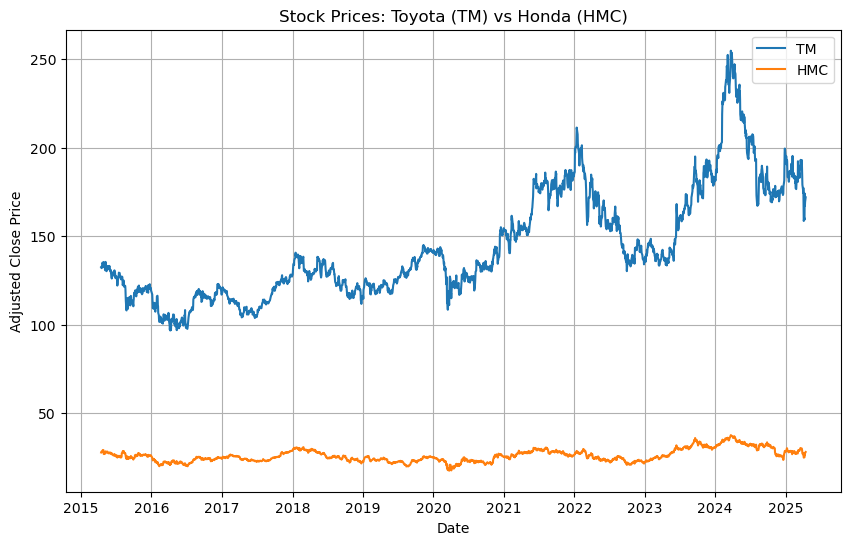

In [21]:
plt.figure(figsize=(10, 6))
for ticker in tickers:
    plt.plot(data.index, data[ticker], label=ticker)

plt.title('Stock Prices: Toyota (TM) vs Honda (HMC)')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.grid(True)
plt.show()

The cointegration test is used to check whether two non-stationary time series move together in a long-term equilibrium relationship. Here, we perform the Engle-Granger cointegration test to check if Toyota and Honda are cointegrated. Honda will be the dependent variable and Toyota be the independent variable. The larger stock is the independent variable and the smaller stock is the dependent variable


In [22]:
# perform cointegration test 

score, p_value, _ = coint(data['HMC'], data['TM'])
print(f'Cointegration test p-value: {p_value:.4f}')

# If p-value is < 0.05 we reject the null so the pairs are cointegrated
if p_value < 0.05:
    print("The pair is cointegrated.")
else:
    print("The pair is not cointegrated.")

Cointegration test p-value: 0.0308
The pair is cointegrated.


The hedge ratio (β) is a key metric in pairs trading that represents the relationship between two assets. It is calculated through an OLS regression, where one asset’s price is regressed on the other. In this case, we regress Honda's stock price on Toyota's stock price. The hedge ratio tells us how much the price of Honda moves in relation to Toyota. For instance, if the hedge ratio is 1.5, it means that for every 1 unit change in Toyota’s stock price, Honda’s stock price moves by 1.5 units. This ratio is used to construct the spread, which is the difference between the two prices adjusted by the hedge ratio, and is central to pairs trading strategies.

In [23]:
# estimate hedge ratio via OLS regression

X = sm.add_constant(data['TM'])  # Independent variable (Toyota)
model = sm.OLS(data['HMC'], X).fit()
beta = model.params['TM']
print(f'Hedge Ratio (β): {beta:.4f}')

Hedge Ratio (β): 0.0868


This hedge ratio tells us that for every 1 unit change in the price of Toyota's stock, Honda's stock is expected to change by 0.0868 units. In other words, Honda’s stock price is less sensitive to changes in Toyota’s stock price. This relationship isn't as strong as others that may have a higher hedge ratio

The spread is calculated as the difference between Honda's stock price and the product of Toyota's stock price and the hedge ratio. 

In [24]:
data['Spread'] = data['HMC'] - beta * data['TM']
data.head()

Ticker,HMC,TM,Spread
Date,,,
2015-04-15,27.896358,132.610245,16.385103
2015-04-16,28.259058,132.514877,16.756081
2015-04-17,28.355787,131.990479,16.898331
2015-04-20,28.218763,132.276505,16.736478
2015-04-21,28.468632,134.755569,16.771151


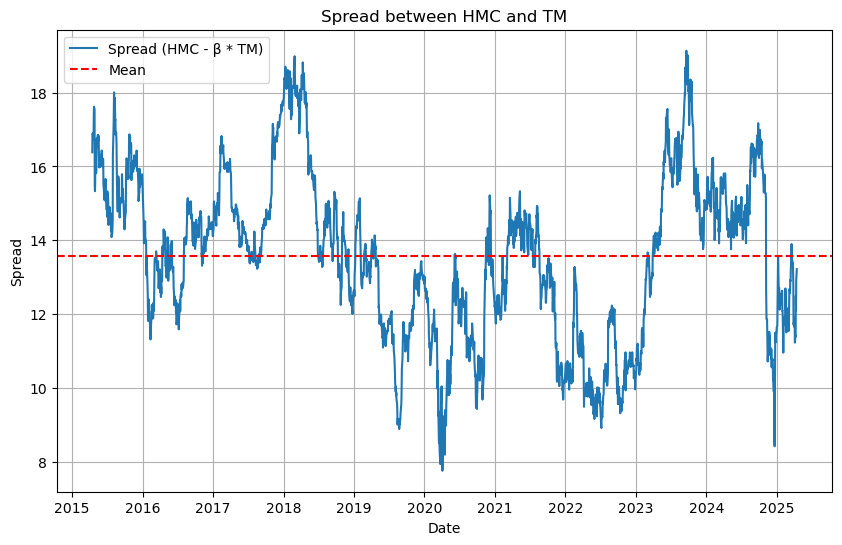

In [25]:
# plot the spread between honda and toyota, adjusted by the hedge ratio

plt.figure(figsize=(10, 6))
plt.plot(data.index, data['Spread'], label='Spread (HMC - β * TM)')
plt.axhline(data['Spread'].mean(), color='red', linestyle='--', label='Mean')
plt.title('Spread between HMC and TM')
plt.xlabel('Date')
plt.ylabel('Spread')
plt.legend()
plt.grid(True)
plt.show()

This graph visualizes the hedge-adjusted spread between Honda and Toyota stock prices relative to its historical average. The plot suggests a mean-reverting relationship, as the spread tends to oscillate around its long-term average . Periods where the spread moves significantly above or below this mean represent potential opportunities for pairs trading strategies betting on a reversion back to the average value. However, the magnitude and duration of these deviations would need further statistical analysis to assess signal strength and risk.


Now we calculate the Z-Score for the spread between Honda and Toyota. The Z-Score standardizes the spread by subtracting its mean and dividing by its standard deviation. This allows us to assess how many standard deviations the current spread is from its average. A Z-Score of 0 indicates that the spread is at its mean, while positive or negative values show how far the spread has deviated. This is a crucial step for identifying potential trading opportunities when the spread deviates significantly from the mean.


In [26]:
# compute the z-score 

data['Z-Score'] = (data['Spread'] - data['Spread'].mean()) / data['Spread'].std()
data.head()

Ticker,HMC,TM,Spread,Z-Score
Date,,,,
2015-04-15,27.896358,132.610245,16.385103,1.259724
2015-04-16,28.259058,132.514877,16.756081,1.425479
2015-04-17,28.355787,131.990479,16.898331,1.489036
2015-04-20,28.218763,132.276505,16.736478,1.416720
2015-04-21,28.468632,134.755569,16.771151,1.432212


In order to decide what to do with our stocks we now define the trading signals based on the Z-score:

Short Spread: If the Z-score exceeds 2, we short the spread.

Long Spread: If the Z-score is less than -2, we go long on the spread.

Exit: We exit the position if the Z-score is between -1 and 1

In [27]:
# define the trading signals

upper_threshold = 2
lower_threshold = -2

data['Position'] = 0
data['Position'] = np.where(data['Z-Score'] > upper_threshold, -1, data['Position'])  # Short Spread
data['Position'] = np.where(data['Z-Score'] < lower_threshold, 1, data['Position'])   # Long Spread
data['Position'] = np.where((data['Z-Score'] < 1) & (data['Z-Score'] > -1), 0, data['Position'])  # Exit

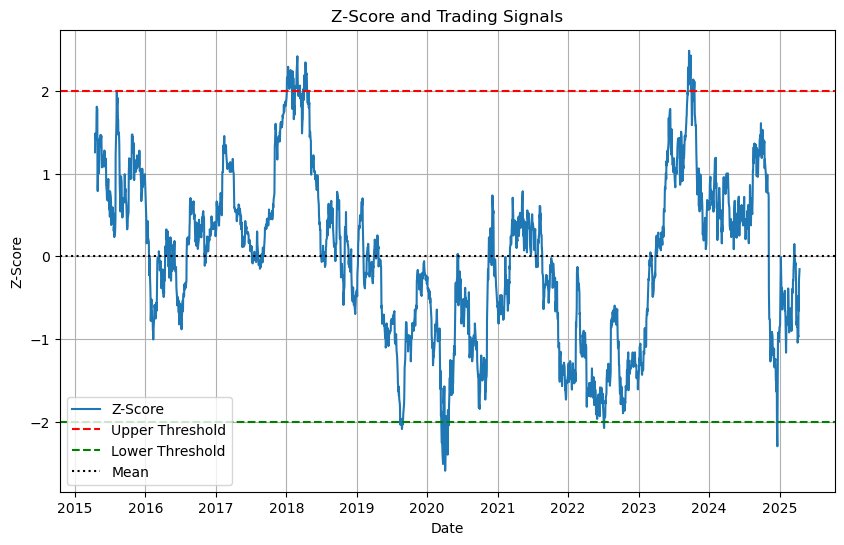

In [28]:
# plot the z-score and trade signals

plt.figure(figsize=(10, 6))
plt.plot(data.index, data['Z-Score'], label='Z-Score')
plt.axhline(upper_threshold, color='red', linestyle='--', label='Upper Threshold')
plt.axhline(lower_threshold, color='green', linestyle='--', label='Lower Threshold')
plt.axhline(0, color='black', linestyle=':', label='Mean')
plt.title('Z-Score and Trading Signals')
plt.xlabel('Date')
plt.ylabel('Z-Score')
plt.legend()
plt.grid(True)
plt.show()

We will now calculate the daily returns for both Honda and Toyota using percentage changes in their respective stock prices. This gives us a sense of how each stock moves on a day-to-day basis.

In [29]:
# calculate daily returns

data['HMC_Return'] = data['HMC'].pct_change()
data['TM_Return'] = data['TM'].pct_change()

data.head()

Ticker,HMC,TM,Spread,Z-Score,Position,HMC_Return,TM_Return
Date,,,,,,,
2015-04-15,27.896358,132.610245,16.385103,1.259724,0,NaN,NaN
2015-04-16,28.259058,132.514877,16.756081,1.425479,0,0.013002,-0.000719
2015-04-17,28.355787,131.990479,16.898331,1.489036,0,0.003423,-0.003957
2015-04-20,28.218763,132.276505,16.736478,1.416720,0,-0.004832,0.002167
2015-04-21,28.468632,134.755569,16.771151,1.432212,0,0.008855,0.018742


Now we compute the return of our trading strategy, which involves taking a long position in Honda and a short position in Toyota. This simulates how the strategy would have performed historically.


In [ ]:
# Strategy Return = (Long HMC, Short TM) * Position

data['Strategy_Return'] = data['Position'].shift(1) * (data['HMC_Return'] - beta * data['TM_Return'])
data.head()

Ticker,HMC,TM,Spread,Z-Score,Position,HMC_Return,TM_Return,Strategy_Return
Date,,,,,,,,
2015-04-15,27.896358,132.610245,16.385103,1.259724,0,NaN,NaN,NaN
2015-04-16,28.259058,132.514877,16.756081,1.425479,0,0.013002,-0.000719,0.0
2015-04-17,28.355787,131.990479,16.898331,1.489036,0,0.003423,-0.003957,0.0
2015-04-20,28.218763,132.276505,16.736478,1.416720,0,-0.004832,0.002167,-0.0
2015-04-21,28.468632,134.755569,16.771151,1.432212,0,0.008855,0.018742,0.0


In [ ]:
# get closer look at strategy returns

data1 = data[data['Strategy_Return'] > 0]
data1.head()

Ticker,HMC,TM,Spread,Z-Score,Position,HMC_Return,TM_Return,Strategy_Return
Date,,,,,,,,
2018-01-09,29.901112,133.720001,18.293523,2.112415,-1,-0.007821,-0.007791,0.007145
2018-01-11,30.380941,136.910004,18.496444,2.203081,-1,-0.005237,0.003739,0.005562
2018-01-12,30.246256,137.199997,18.336586,2.131656,-1,-0.004433,0.002118,0.004617
2018-01-16,30.077888,137.970001,18.101378,2.026564,-1,-0.005567,0.005612,0.006054
2018-01-18,30.187326,138.630005,18.153524,2.049863,-1,-0.012937,-0.014852,0.011648


The cumulative return is calculated by compounding the strategy's returns over time. This gives us an overall measure of how the trading strategy performs over the entire period.

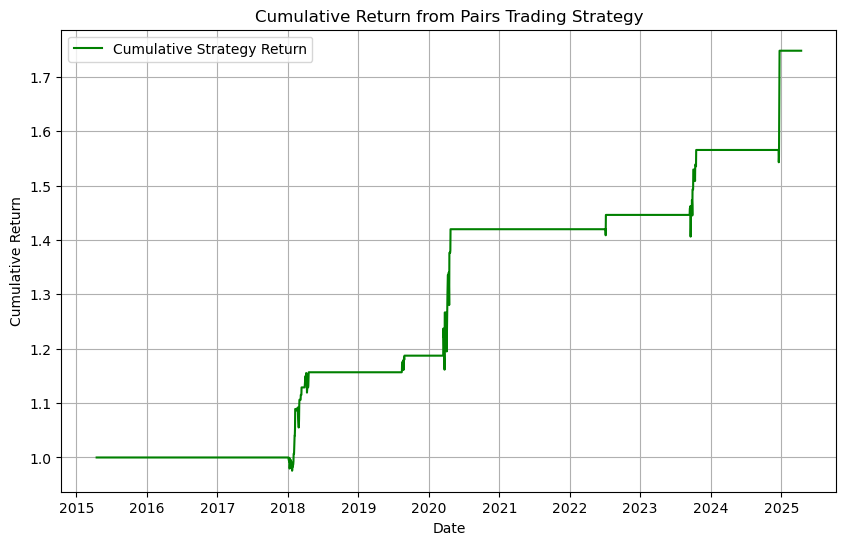

In [32]:
# calculate cumulative returns

data['Cumulative_Return'] = (1 + data['Strategy_Return']).cumprod()

plt.figure(figsize=(10, 6))
plt.plot(data.index, data['Cumulative_Return'], label='Cumulative Strategy Return', color='green')
plt.title('Cumulative Return from Pairs Trading Strategy')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True)
plt.legend()
plt.show()

So our trading strategy will give us about 1.7 times our original portfolio, not bad

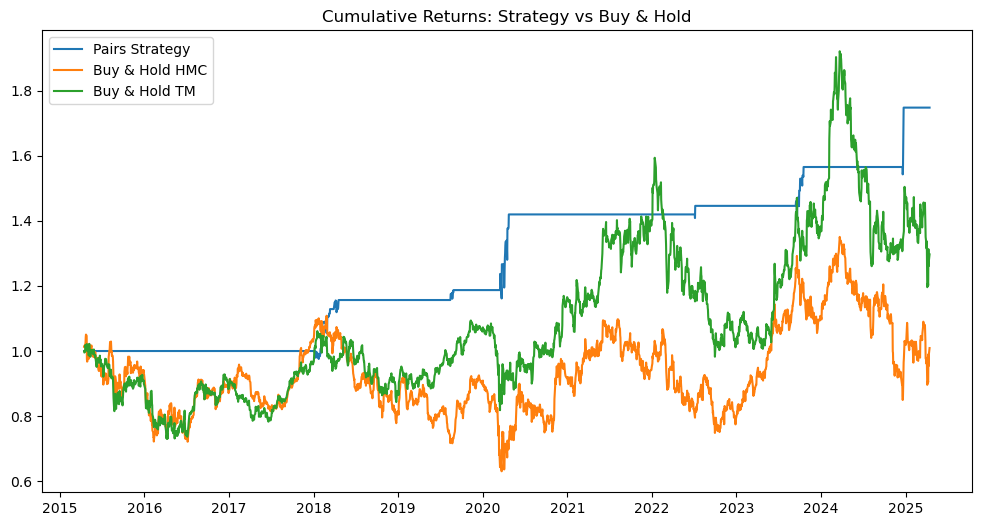

In [33]:
# compare cumulative returns with buy & hold strategy

data['HMC_Cum'] = (1 + data['HMC_Return']).cumprod()
data['TM_Cum'] = (1 + data['TM_Return']).cumprod()

plt.figure(figsize=(12,6))
plt.plot(data['Cumulative_Return'], label='Pairs Strategy')
plt.plot(data['HMC_Cum'], label='Buy & Hold HMC')
plt.plot(data['TM_Cum'], label='Buy & Hold TM')
plt.legend()
plt.title("Cumulative Returns: Strategy vs Buy & Hold")
plt.show()

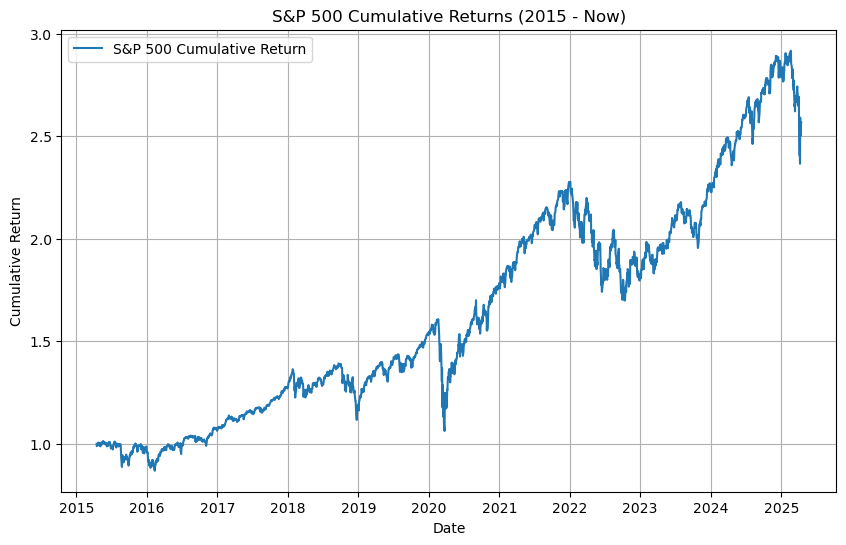

In [34]:
# compare vs s&p500

sp500 = yf.Ticker("^GSPC")
sp500 = sp500.history(start="2015-04-15", end="2025-04-15", auto_adjust=False)['Adj Close']
sp500['Daily Return'] = sp500.pct_change()
sp500['Cumulative Return'] = (1 + sp500['Daily Return']).cumprod()

# Plot the cumulative return
plt.figure(figsize=(10, 6))
plt.plot(sp500['Cumulative Return'], label='S&P 500 Cumulative Return')
plt.title('S&P 500 Cumulative Returns (2015 - Now)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

The sharpe ratio measures the risk-adjusted return of your strategy. It compares the average return to the amount of risk taken, using volatility as a proxy for risk. A higher sharpe ratio is better, it means you're getting more return for each unit of risk

Max drawdown represents the largest drop from a peak to the bottom in the cumulative return over the strategy period. It's a way to measure risk of loss in worst-case scenarios.

In [35]:
# performance metrics

sharpe_ratio = data['Strategy_Return'].mean() / data['Strategy_Return'].std() * np.sqrt(252)
print(f'Sharpe Ratio: {sharpe_ratio:.4f}')

# Max Drawdown
cumulative_max = data['Cumulative_Return'].cummax()
drawdown = (cumulative_max - data['Cumulative_Return']) / cumulative_max
max_drawdown = drawdown.max()
print(f'Max Drawdown: {max_drawdown:.2%}')

Sharpe Ratio: 0.7690
Max Drawdown: 6.11%


The sharpe ratio of 0.7461 means the strategy returns about 0.75 units of excess return for every unit of risk, on an annualized basis. We want the sharpe ratio to be over 1, but not much higher than that
The max drawdown of 6.11% means the most you could have lost during this period was 6.11%.



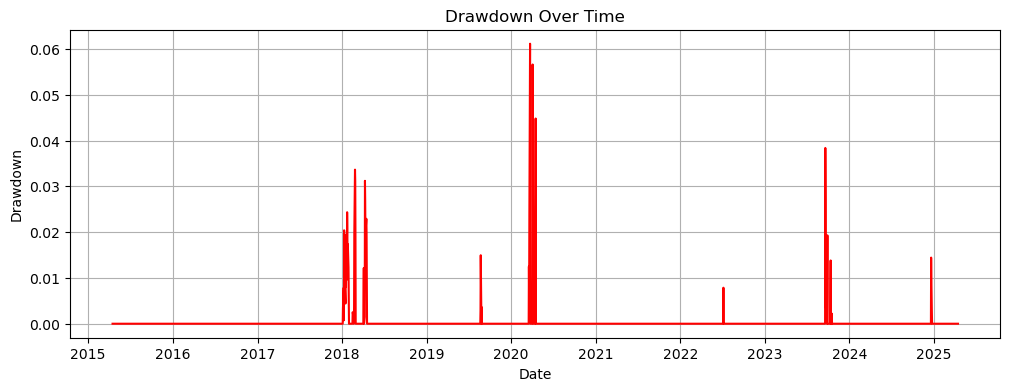

In [36]:
# plot the drawdown

plt.figure(figsize=(12, 4))
plt.plot(drawdown, color='red')
plt.title('Drawdown Over Time')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.grid(True)
plt.show()

### Thank you! Hopefully, you now understand the concepts and feel like a finance bro, ready to hit the markets and make some money!